<a href="https://colab.research.google.com/github/Afkar5115/Kecerdasan_Buatan_TI-1B_2025/blob/main/Jobsheet_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JOBSHEET 8: Supervise Learning Regression dan Classification


## Latihan

### 1.Decision Tree

In [ ]:
import pandas as pd

# Membaca file iris.csv
iris = pd.read_csv('Iris.csv')


In [ ]:
# Melihat informasi dataset
iris.info()

# melihat informasi dataset pada 5 baris pertama
iris.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# menghilangkan kolom yang tidak penting
iris.drop('Id',axis=1,inplace=True)


In [ ]:
# memisahkan atribut dan label
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm' ]]
y = iris['Species']

# Membagi dataset menjadi data latih & data uji
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=123)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# membuat model Decision Tree
tree_model = DecisionTreeClassifier()

# Melatih model dengan menggunakan data latih
tree_model = tree_model.fit(X_train, y_train)


In [ ]:
# Evaluasi Model
from sklearn.metrics import accuracy_score

y_pred = tree_model.predict(X_test)

acc_secore = round(accuracy_score(y_pred, y_test), 3)

print('Accuracy: ', acc_secore)


Accuracy:  0.933


In [ ]:
# prediksi model dengan tree_model.predict([[SepalLength, SepalWidth, PetalLength, PetalWidth]])
print(tree_model.predict([[6.2, 3.4, 5.4, 2.3]])[0])


Iris-virginica


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.tree import export_graphviz
export_graphviz(
    tree_model,
    out_file = "iris_tree.dot",
    feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
    class_names = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica' ],
    rounded= True,
    filled =True)


### 2.Linear Regression

In [ ]:
import numpy as np

#buat data jumlah kamar
bedrooms = np.array([1,1,2,2,3,4,4,5,5,5])

#data harga rumah. asumsi dalam dollar
house_price = np.array([15000, 18000, 27000, 34000, 50000, 68000, 65000, 81000,85000, 90000])


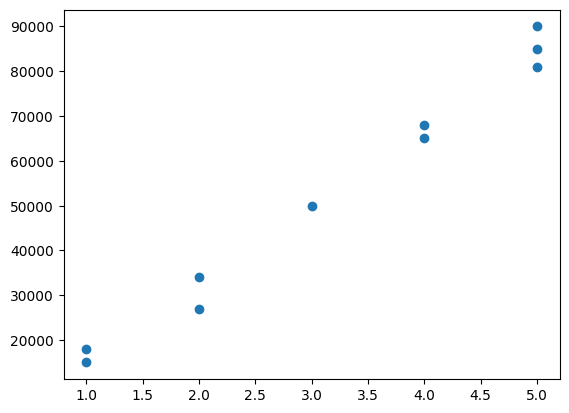

In [ ]:
# menampilkan scatter plot dari dataset
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(bedrooms, house_price)


In [ ]:
from sklearn.linear_model import LinearRegression

# latih model dengan Linear Regression.fit()
bedrooms = bedrooms.reshape(-1, 1)
linreg = LinearRegression()
linreg.fit(bedrooms, house_price)


LinearRegression()

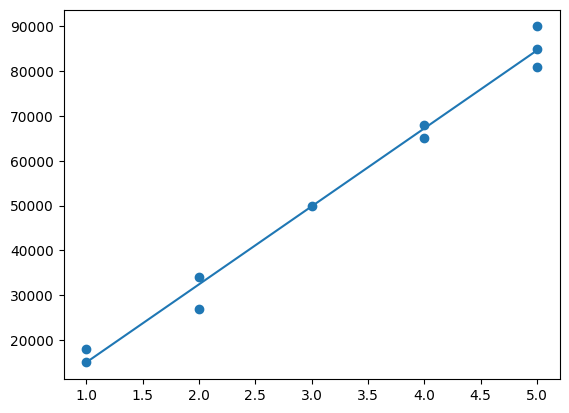

In [ ]:
# menampilkan plot hubungan antara jumlah kamar dengan harga rumah
plt.scatter(bedrooms, house_price)
plt.plot(bedrooms, linreg.predict(bedrooms))


In [ ]:
# Data testing
# Jumlah kamar yang ingin diprediksi harganya
X_test = np.array([[6], [7]])

# Melakukan prediksi harga kamar
y_pred = linreg.predict(X_test)

# Menampilkan hasil prediksi
for i in range(len(X_test)):
    print("Jumlah kamar:", X_test[i][0])
    print("Prediksi harga kamar:", y_pred[i])
    print()


Jumlah kamar: 6
Prediksi harga kamar: 102110.16949152542

Jumlah kamar: 7
Prediksi harga kamar: 119542.37288135593



In [ ]:
# uji akurasi model
linreg.score(X_test, y_pred)


1.0

### 3.Logistic Regression

In [ ]:
import pandas as pd

# membaca dataset dan mengubahnya menjadi dataframe
df = pd.read_csv('Social_Network_Ads.csv')


In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
# drop kolom yang tidak diperlukan
data = df.drop(columns=['User ID'])

# jalankan proses one-hot encoding dengan pd.get_dummies()
data = pd.get_dummies(data)
data


,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,19,19000,0,False,True
1,35,20000,0,False,True
2,26,43000,0,True,False
3,27,57000,0,True,False
4,19,76000,0,False,True
...,...,...,...,...,...
395,46,41000,1,True,False
396,51,23000,1,False,True
397,50,20000,1,True,False
398,36,33000,0,False,True


In [ ]:
# pisahkan atribut dan label
predictions = ['Age' , 'EstimatedSalary' , 'Gender_Female' , 'Gender_Male']
X = data[predictions]
y = data['Purchased']


In [ ]:
# lakukan normalisasi terhadap data yang kita miliki
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
scaled_data = scaler.transform(X)
scaled_data = pd.DataFrame(scaled_data, columns= X.columns)
scaled_data.head()


,Age,EstimatedSalary,Gender_Female,Gender_Male
0,-1.781797,-1.490046,-1.020204,1.020204
1,-0.253587,-1.460681,-1.020204,1.020204
2,-1.113206,-0.785290,0.980196,-0.980196
3,-1.017692,-0.374182,0.980196,-0.980196
4,-1.781797,0.183751,-1.020204,1.020204


In [ ]:
from sklearn.model_selection import train_test_split

# bagi data menjadi train dan test untuk setiap atribut dan label
X_train, X_test, y_train, y_test = train_test_split(scaled_data, y, test_size=0.2, random_state=1)


In [ ]:
from sklearn import linear_model

# latih model dengan fungsi fit
model = linear_model.LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
# uji akurasi model
model.score(X_test, y_test)


0.825

## Tugas Praktikum

### 1.Buatlah model maching learning untuk memprediksi calon konsumen melakukan transaksi atau tidak.

Tampilan 5 data teratas:
         ID Jenis_Kelamin  Umur        Gaji  Transaksi
0  15624510          Pria    19   285000000          0
1  15810944          Pria    35   300000000          0
2  15668575        Wanita    26   645000000          0
3  15603246        Wanita    27   855000000          0
4  15804002          Pria    19  1140000000          0

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             400 non-null    int64 
 1   Jenis_Kelamin  400 non-null    object
 2   Umur           400 non-null    int64 
 3   Gaji           400 non-null    int64 
 4   Transaksi      400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

Deskripsi Statistik Dataset:
                 ID        Umur          Gaji   Transaksi
count  4.000000e+02  400.000000  4.000000e+02  400.000000
mean   1.569154e+07   3

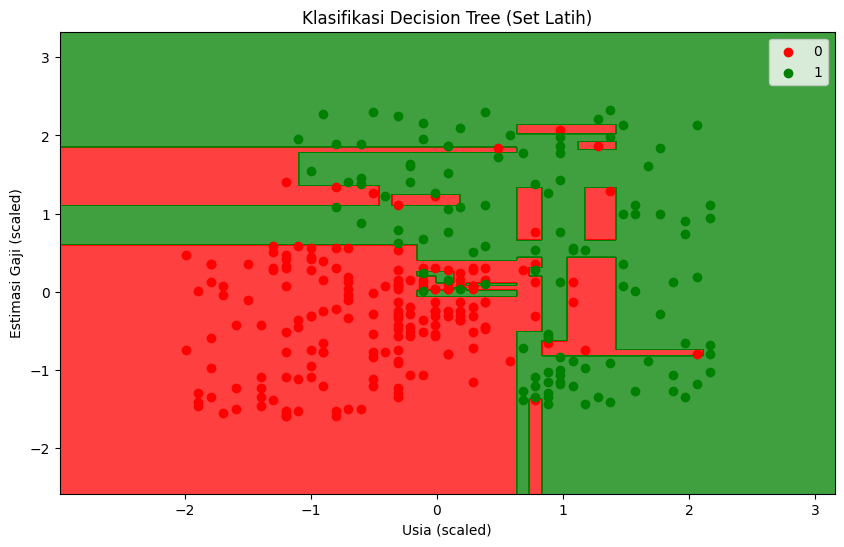

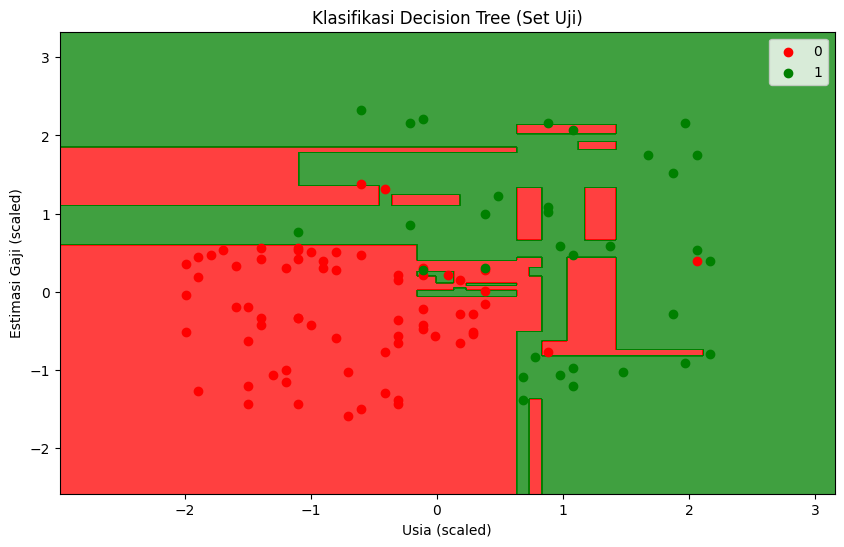


--- Visualisasi Diagram Pohon Keputusan (Versi Detail) ---


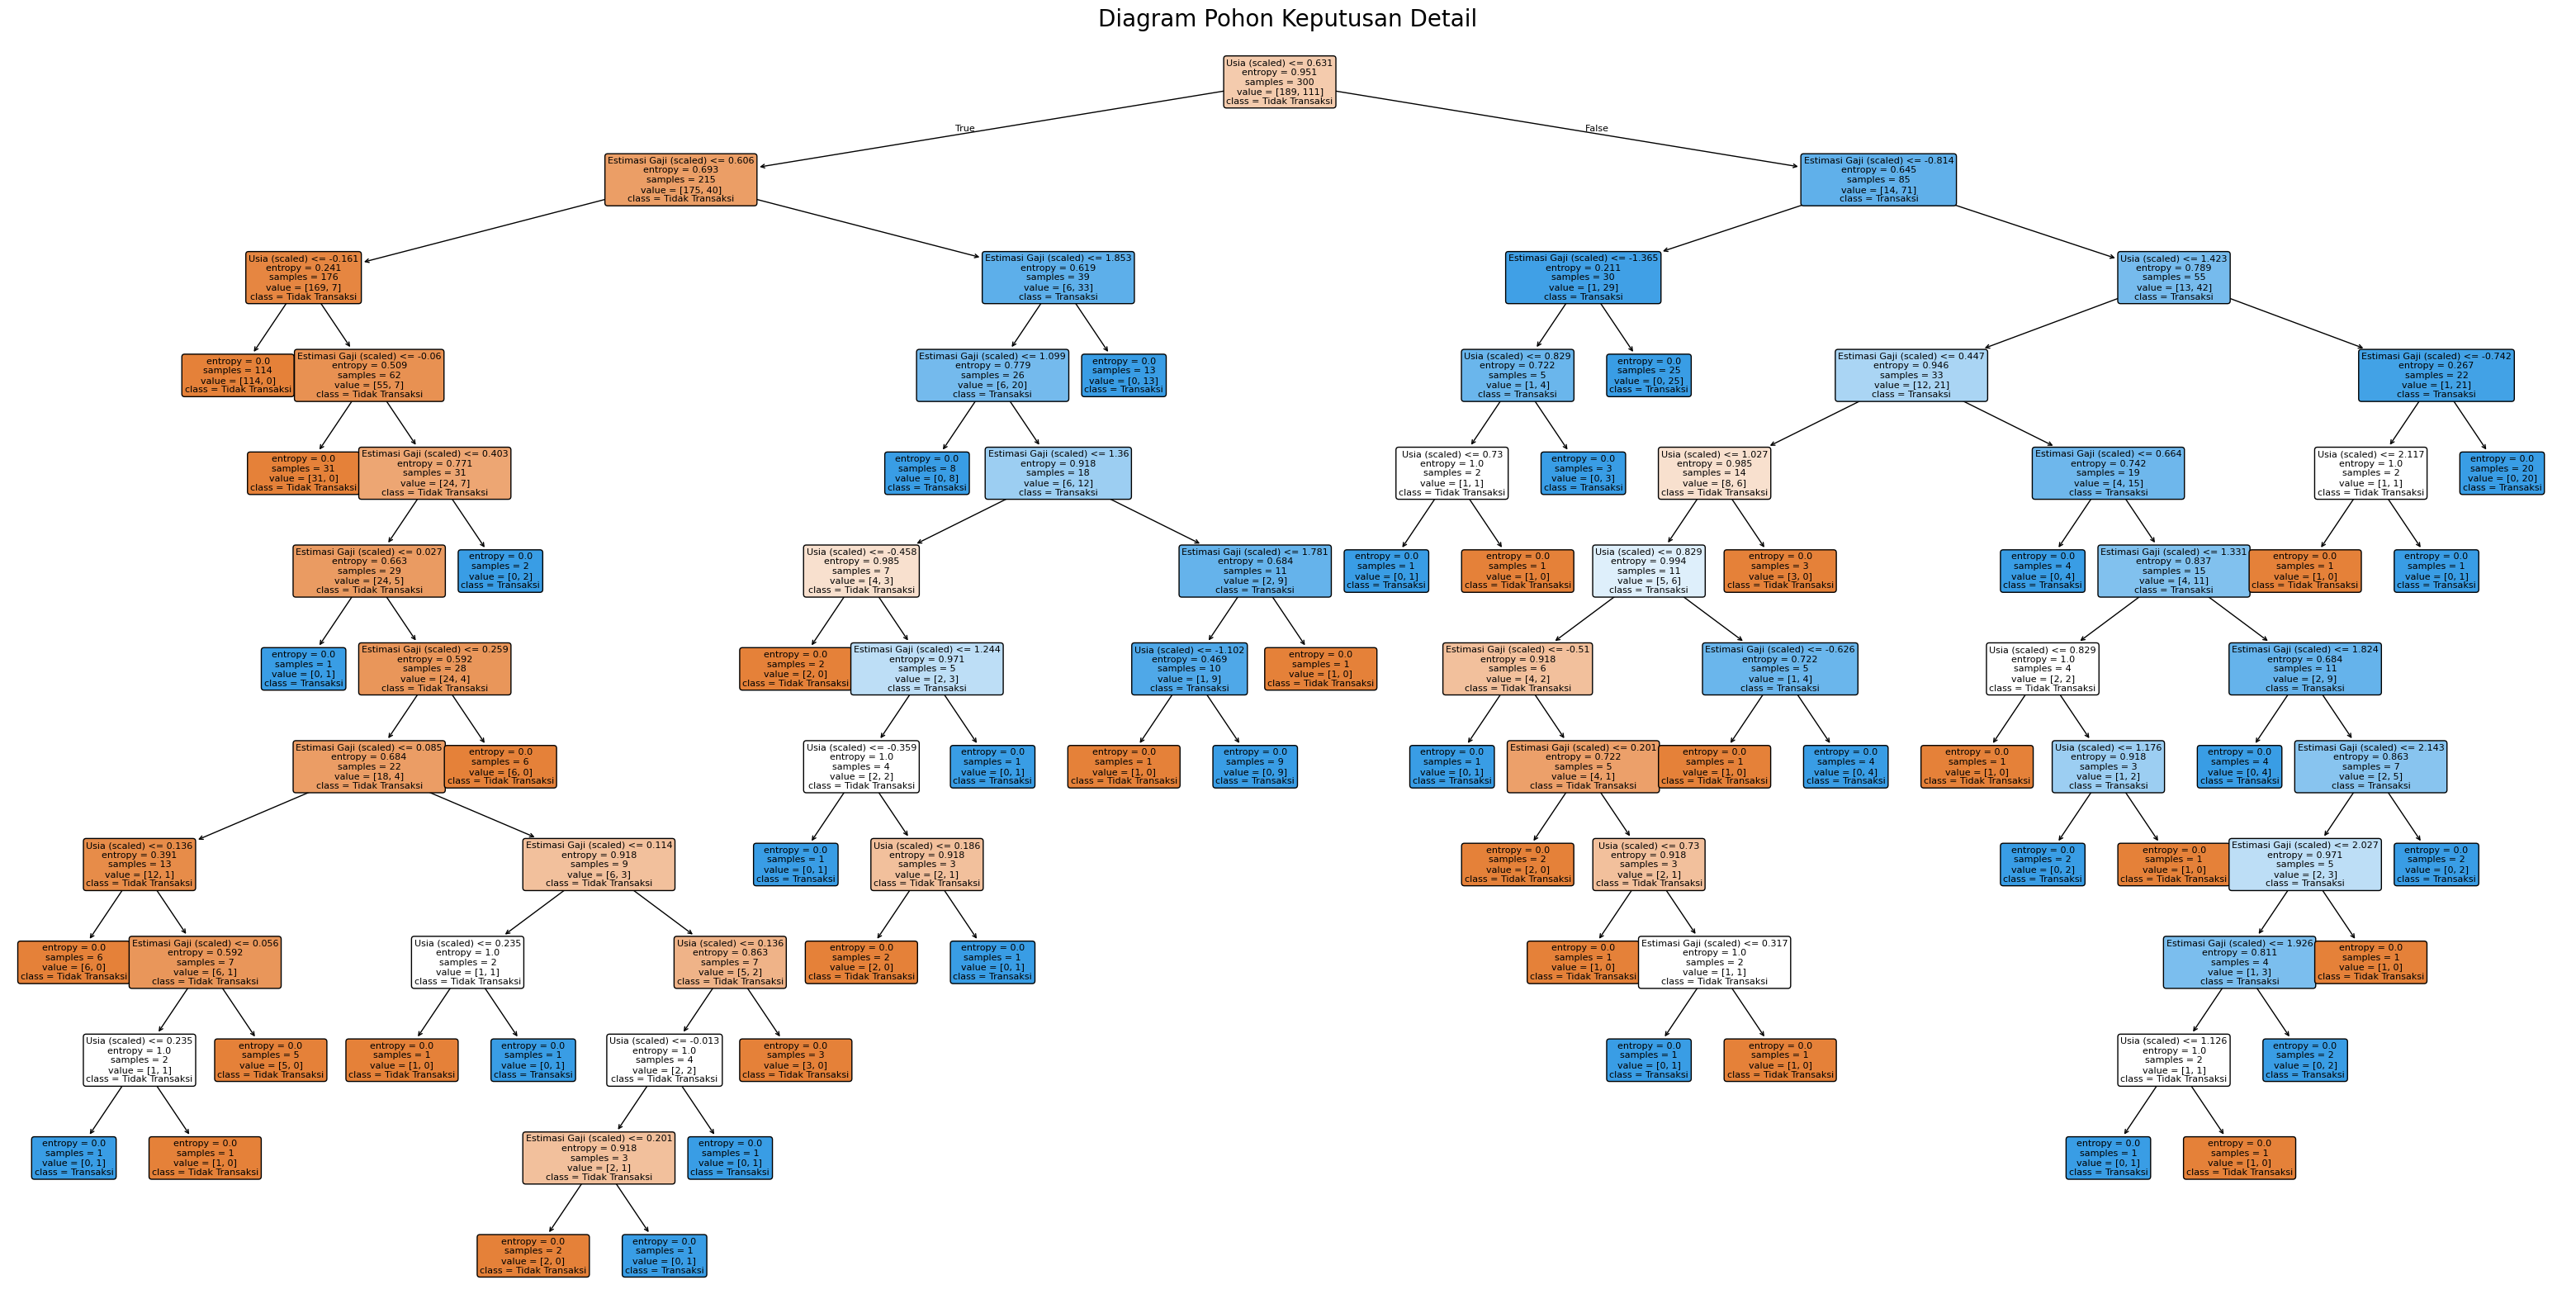


--- Visualisasi Diagram Pohon Keputusan (Versi Sederhana) ---


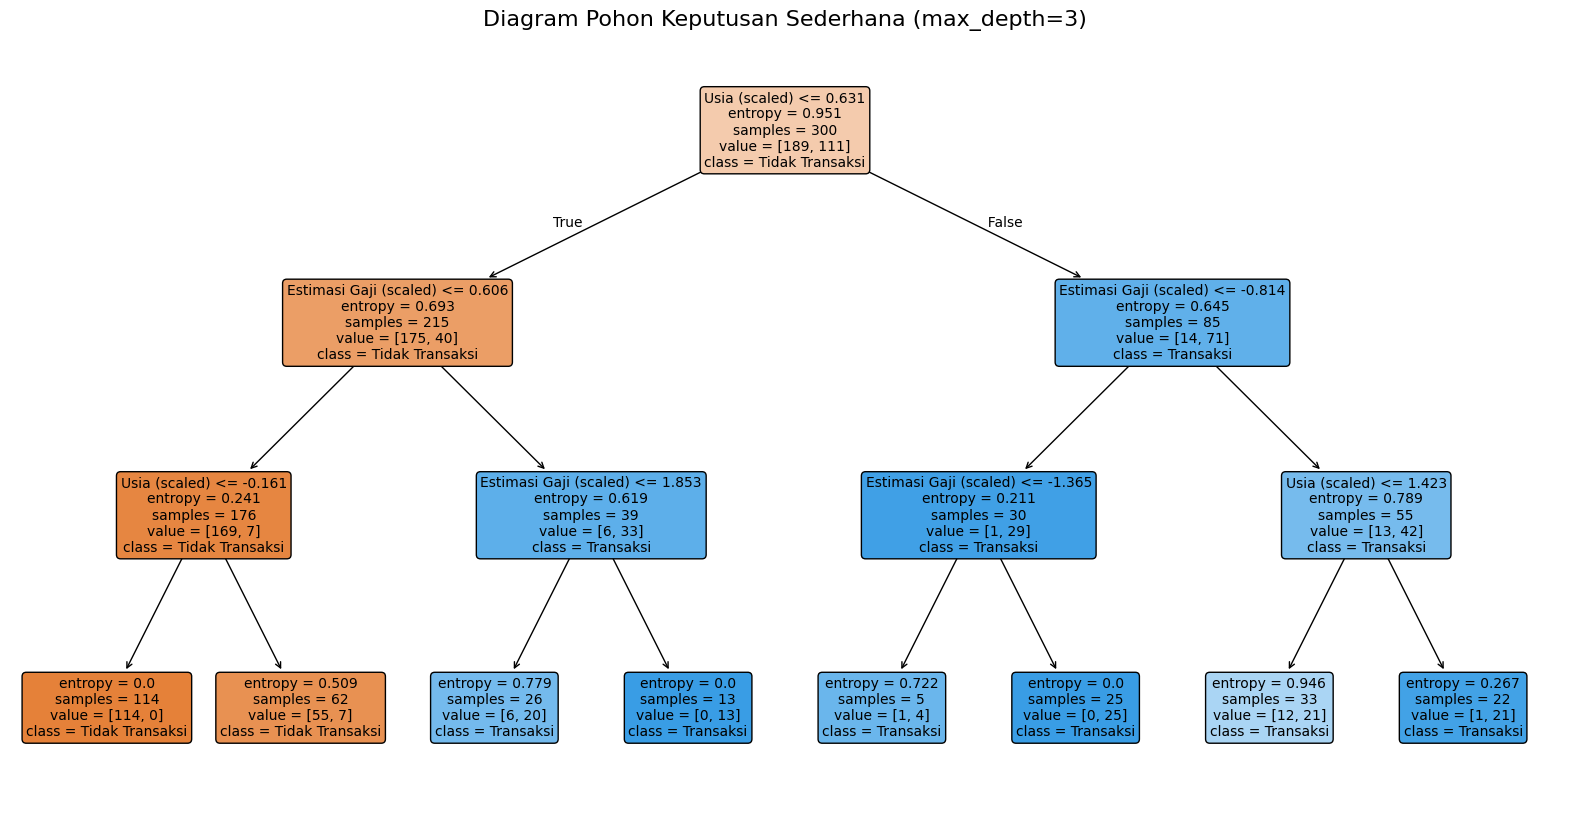


--- Hasil Regresi Logistik ---

Perbandingan Prediksi vs Aktual (10 sampel pertama):
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]]

Confusion Matrix (Regresi Logistik):
[[65  3]
 [ 8 24]]
Akurasi (Regresi Logistik): 0.8900 atau 89.00%


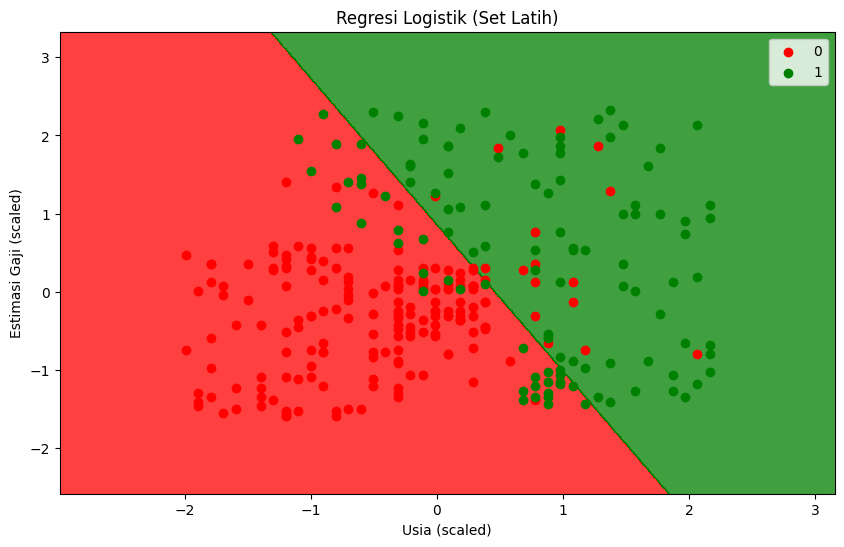

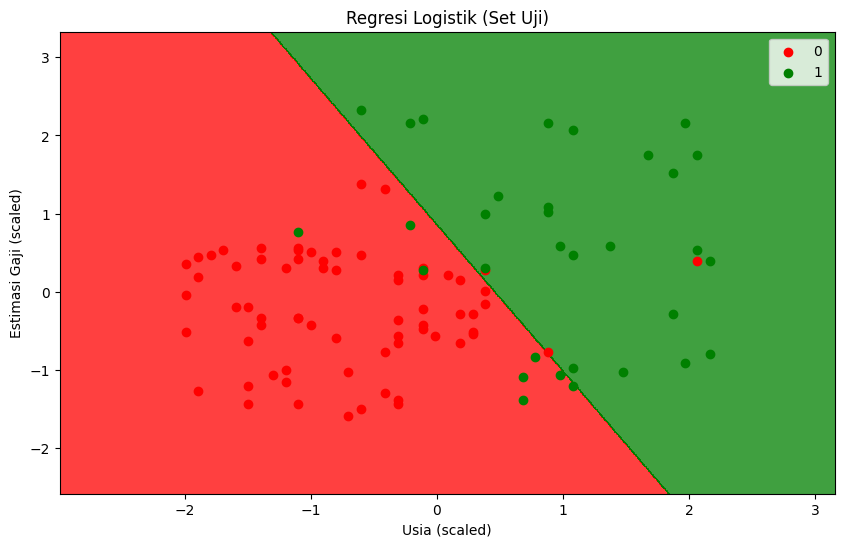

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
from sklearn import tree
import warnings

# Mengabaikan warnings untuk output yang lebih bersih
warnings.filterwarnings('ignore')

# --- 1. Persiapan Data ---

## Memuat Dataset
# Dataset dimuat dari file CSV 'iklan_sosmed.csv'
dataset = pd.read_csv('iklan_sosmed.csv', delimiter=';')
print("Tampilan 5 data teratas:")
print(dataset.head())

## Informasi Dasar Dataset
print("\nInformasi Dataset:")
dataset.info()

print("\nDeskripsi Statistik Dataset:")
print(dataset.describe())

## Memisahkan Fitur (X) dan Target (y)
# X (fitur) diambil dari kolom 'Usia' (indeks 2) dan 'EstimasiGaji' (indeks 3)
# y (target) diambil dari kolom 'JumlahTransaksi' (indeks 4)
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

print("\nContoh data Fitur (X):")
print(X[:5])
print("\nContoh data Target (y):")
print(y[:5])

## Membagi Data menjadi Data Latih dan Data Uji
# Data dibagi dengan proporsi 75% data latih dan 25% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

print(f"\nUkuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

## Penskalaan Fitur (Feature Scaling)
# Menyamakan skala nilai pada fitur 'Usia' dan 'EstimasiGaji'
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("\nContoh X_train setelah penskalaan:")
print(X_train[:5])
print("\nContoh X_test setelah penskalaan:")
print(X_test[:5])

# --- 2. Pemodelan dengan Decision Tree Classifier ---

print("\n--- Hasil Klasifikasi Decision Tree ---")

## Melatih Model Decision Tree
# Membuat dan melatih model dengan kriteria 'entropy'
classifier_dt = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier_dt.fit(X_train, y_train)

## Memprediksi Hasil pada Data Uji
y_pred_dt = classifier_dt.predict(X_test)

print("\nPerbandingan Prediksi vs Aktual (10 sampel pertama):")
print(np.concatenate((y_pred_dt.reshape(len(y_pred_dt), 1), y_test.reshape(len(y_test), 1)), 1)[:10])

## Evaluasi Model: Confusion Matrix dan Akurasi
cm_dt = confusion_matrix(y_test, y_pred_dt)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("\nConfusion Matrix (Decision Tree):")
print(cm_dt)
print(f"Akurasi (Decision Tree): {accuracy_dt:.4f} atau {accuracy_dt*100:.2f}%")

## Visualisasi Hasil Decision Tree (Data Latih)
plt.figure(figsize=(10, 6))
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01))
plt.contourf(X1, X2, classifier_dt.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)
plt.title('Klasifikasi Decision Tree (Set Latih)')
plt.xlabel('Usia (scaled)')
plt.ylabel('Estimasi Gaji (scaled)')
plt.legend()
plt.show()

## Visualisasi Hasil Decision Tree (Data Uji)
plt.figure(figsize=(10, 6))
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01))
plt.contourf(X1, X2, classifier_dt.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)
plt.title('Klasifikasi Decision Tree (Set Uji)')
plt.xlabel('Usia (scaled)')
plt.ylabel('Estimasi Gaji (scaled)')
plt.legend()
plt.show()


# 1. Visualisasi Pohon Keputusan Lengkap yang Rapi dan Mudah Dibaca
print("\n--- Visualisasi Diagram Pohon Keputusan (Versi Detail) ---")
plt.figure(figsize=(40, 20)) # <--- MODIFIKASI: Ukuran gambar diperbesar secara signifikan
tree.plot_tree(classifier_dt,
               feature_names=['Usia (scaled)', 'Estimasi Gaji (scaled)'],
               class_names=['Tidak Transaksi', 'Transaksi'],
               filled=True,
               rounded=True,
               fontsize=8) # <--- MODIFIKASI: Ukuran font disesuaikan agar pas
plt.title('Diagram Pohon Keputusan Detail', fontsize=20)
plt.show()

# 2. (OPSIONAL) Visualisasi Pohon yang Disederhanakan untuk Interpretasi Mudah
print("\n--- Visualisasi Diagram Pohon Keputusan (Versi Sederhana) ---")
# Latih model baru dengan batasan kedalaman (max_depth)
classifier_dt_pruned = DecisionTreeClassifier(criterion='entropy', random_state=0, max_depth=3)
classifier_dt_pruned.fit(X_train, y_train)

plt.figure(figsize=(20, 10)) # Ukuran gambar disesuaikan untuk pohon yang lebih kecil
tree.plot_tree(classifier_dt_pruned,
               feature_names=['Usia (scaled)', 'Estimasi Gaji (scaled)'],
               class_names=['Tidak Transaksi', 'Transaksi'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Diagram Pohon Keputusan Sederhana (max_depth=3)', fontsize=16)
plt.show()



# --- 3. Pemodelan dengan Logistic Regression ---

print("\n--- Hasil Regresi Logistik ---")

## Melatih Model Logistic Regression
classifier_lr = LogisticRegression(random_state=0)
classifier_lr.fit(X_train, y_train)

## Memprediksi Hasil pada Data Uji
y_pred_lr = classifier_lr.predict(X_test)

print("\nPerbandingan Prediksi vs Aktual (10 sampel pertama):")
print(np.concatenate((y_pred_lr.reshape(len(y_pred_lr), 1), y_test.reshape(len(y_test), 1)), 1)[:10])

## Evaluasi Model: Confusion Matrix dan Akurasi
cm_lr = confusion_matrix(y_test, y_pred_lr)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("\nConfusion Matrix (Regresi Logistik):")
print(cm_lr)
print(f"Akurasi (Regresi Logistik): {accuracy_lr:.4f} atau {accuracy_lr*100:.2f}%")

## Visualisasi Hasil Logistic Regression (Data Latih)
plt.figure(figsize=(10, 6))
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01))
plt.contourf(X1, X2, classifier_lr.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)
plt.title('Regresi Logistik (Set Latih)')
plt.xlabel('Usia (scaled)')
plt.ylabel('Estimasi Gaji (scaled)')
plt.legend()
plt.show()

## Visualisasi Hasil Logistic Regression (Data Uji)
plt.figure(figsize=(10, 6))
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01))
plt.contourf(X1, X2, classifier_lr.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)
plt.title('Regresi Logistik (Set Uji)')
plt.xlabel('Usia (scaled)')
plt.ylabel('Estimasi Gaji (scaled)')
plt.legend()
plt.show()

### 2.Buatlah model maching learning untuk memprediksi gaji pegawai berdasarkan masa kerjanya.

Data Awal:
   Tahun_Pengalaman       Gaji
0               1.1  590145000
1               1.3  693075000
2               1.5  565965000
3               2.0  652875000
4               2.2  598365000


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tahun_Pengalaman  30 non-null     float64
 1   Gaji              30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


Hasil Prediksi vs Gaji Aktual:
   Gaji Aktual  Gaji Prediksi
0    565965000   6.112344e+08
1   1835865000   1.840494e+09
2    856215000   9.744249e+08
3    948270000   9.464871e+08
4   1754535000   1.728743e+09
5   1641465000   1.616993e+09




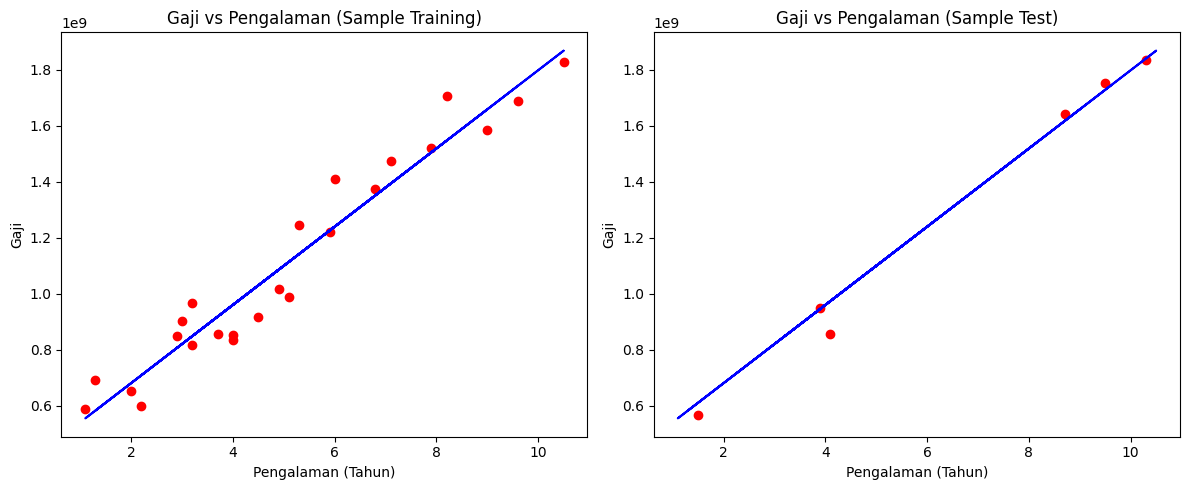

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ## Load Dataset
# load dataset
dataset = pd.read_csv('Data_Gaji.csv', delimiter=';')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 1].values

# ## Menampilkan Properti Data
# Menampilkan beberapa baris pertama dari dataset
print("Data Awal:")
print(dataset.head())
print("\n")

# Menampilkan informasi ringkas tentang dataset
print("Informasi Dataset:")
dataset.info()
print("\n")


# ## Membagi Data menjadi Data Train dan Data Test
# Import library untuk membagi data
from sklearn.model_selection import train_test_split

# Bagi dataset menjadi 80% data training dan 20% data test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


# ## Membuat Model Regresi Linear Sederhana
# Import library Regresi Linear
from sklearn.linear_model import LinearRegression

# Inisialisasi model Regresi Linear
regressor = LinearRegression()

# Latih model menggunakan data training
regressor.fit(X_train, y_train)


# ## Memprediksi Hasil Test
# Lakukan prediksi pada data test
y_pred = regressor.predict(X_test)

# Menampilkan hasil prediksi dan perbandingannya dengan data aktual
print("Hasil Prediksi vs Gaji Aktual:")
hasil_perbandingan = pd.DataFrame({'Gaji Aktual': y_test, 'Gaji Prediksi': y_pred})
print(hasil_perbandingan)
print("\n")


# ### Melakukan Visualisasi Data Train dan Data Test
# Visualisasikan hasil pada sample training
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Gaji vs Pengalaman (Sample Training)')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji')

# Visualisasikan hasil pada sample test
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue') # Garis regresi tetap sama
plt.title('Gaji vs Pengalaman (Sample Test)')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji')

plt.tight_layout()
plt.show()

### 3.Bandingkan hasil akurasi algoritma Decision Tree dan Logistic Regression. Algoritma apakah yang paling tinggi akurasinya?

  Berdasarkan hasil pengujian, model Decision Tree berhasil mencapai akurasi 91%. Sementara itu, model Logistic Regression mendapatkan akurasi 89%.

  Meskipun hasilnya tidak berbeda jauh, Decision Tree terbukti sedikit lebih unggul dalam menebak calon pelanggan mana yang akan melakukan pembelian. Hal ini bisa jadi karena Decision Tree lebih fleksibel dalam menemukan pola-pola hubungan yang rumit di dalam data, sesuatu yang mungkin tidak bisa diikuti oleh Logistic Regression.

### 4.Gunakan parameter tunning pada masing-masing algoritma untuk meningkatkan akurasi dari setiap algoritma.

#### Tuning Nomer 1


--- Hasil Klasifikasi Decision Tree (Original) ---
Akurasi Awal (Decision Tree): 91.00%

--- Tuning Hyperparameter Decision Tree dengan GridSearchCV ---
Parameter Terbaik (Decision Tree): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Akurasi Setelah Tuning (Decision Tree): 92.00%

--- Hasil Regresi Logistik (Original) ---
Akurasi Awal (Regresi Logistik): 89.00%

--- Tuning Hyperparameter Regresi Logistik dengan GridSearchCV ---
Parameter Terbaik (Regresi Logistik): {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Akurasi Setelah Tuning (Regresi Logistik): 91.00%


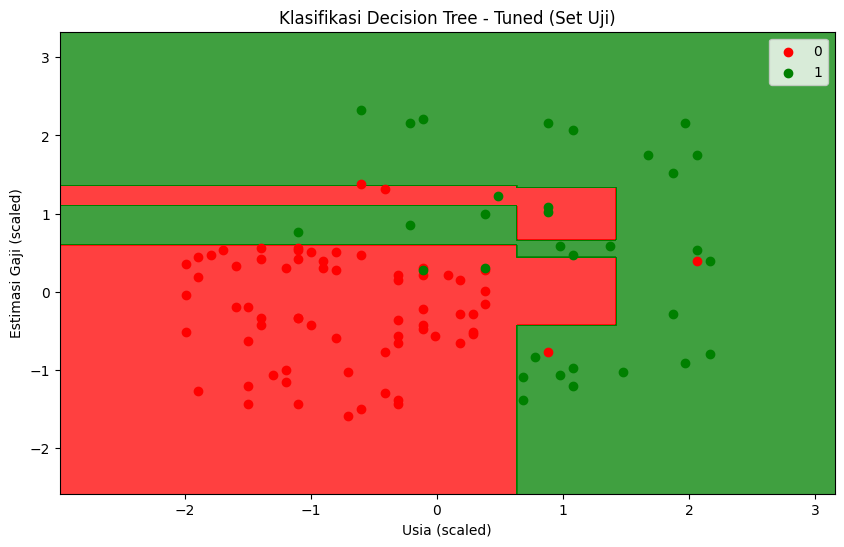

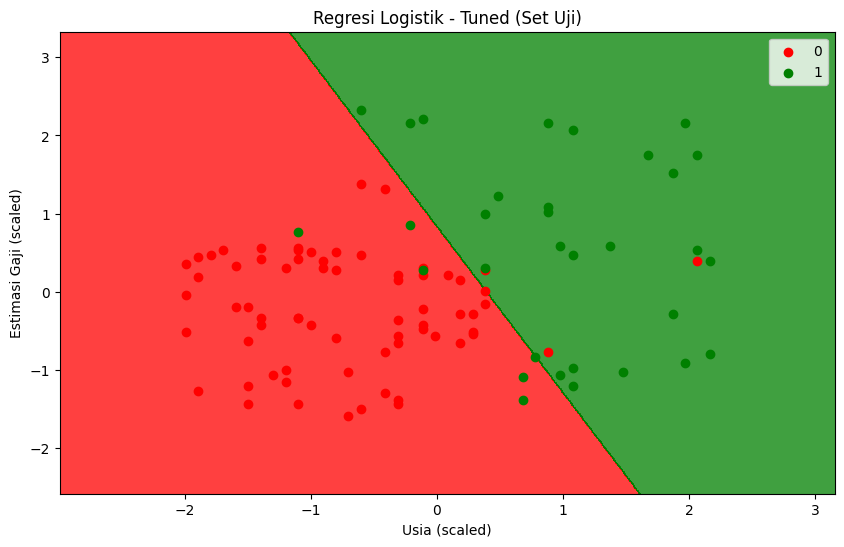

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
from sklearn import tree
import warnings

# Mengabaikan warnings untuk output yang lebih bersih
warnings.filterwarnings('ignore')

# --- 1. Persiapan Data ---

## Memuat Dataset
dataset = pd.read_csv('iklan_sosmed.csv', delimiter=';')
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

## Membagi Data menjadi Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## Penskalaan Fitur (Feature Scaling)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


# --- 2. Pemodelan dengan Decision Tree Classifier (Original) ---

print("\n--- Hasil Klasifikasi Decision Tree (Original) ---")
classifier_dt = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier_dt.fit(X_train, y_train)
y_pred_dt = classifier_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Akurasi Awal (Decision Tree): {accuracy_dt*100:.2f}%")


# --- 3. Hyperparameter Tuning untuk Decision Tree ---

print("\n--- Tuning Hyperparameter Decision Tree dengan GridSearchCV ---")
# Menentukan parameter grid untuk diuji
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Membuat objek GridSearchCV
grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                              param_grid=param_grid_dt,
                              cv=10,
                              n_jobs=-1,
                              scoring='accuracy')

# Menjalankan pencarian pada data latih
grid_search_dt.fit(X_train, y_train)

# Mendapatkan parameter terbaik
best_params_dt = grid_search_dt.best_params_
print(f"Parameter Terbaik (Decision Tree): {best_params_dt}")

# Melatih ulang model dengan parameter terbaik
best_classifier_dt = DecisionTreeClassifier(**best_params_dt, random_state=0)
best_classifier_dt.fit(X_train, y_train)

# Memprediksi dan mengevaluasi model yang sudah di-tuning
y_pred_dt_tuned = best_classifier_dt.predict(X_test)
accuracy_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
print(f"Akurasi Setelah Tuning (Decision Tree): {accuracy_dt_tuned*100:.2f}%")


# --- 4. Pemodelan dengan Logistic Regression (Original) ---

print("\n--- Hasil Regresi Logistik (Original) ---")
classifier_lr = LogisticRegression(random_state=0)
classifier_lr.fit(X_train, y_train)
y_pred_lr = classifier_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Akurasi Awal (Regresi Logistik): {accuracy_lr*100:.2f}%")


# --- 5. Hyperparameter Tuning untuk Logistic Regression ---

print("\n--- Tuning Hyperparameter Regresi Logistik dengan GridSearchCV ---")
# Menentukan parameter grid untuk diuji
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Membuat objek GridSearchCV
grid_search_lr = GridSearchCV(estimator=LogisticRegression(random_state=0),
                              param_grid=param_grid_lr,
                              cv=10,
                              n_jobs=-1,
                              scoring='accuracy')

# Menjalankan pencarian pada data latih
grid_search_lr.fit(X_train, y_train)

# Mendapatkan parameter terbaik
best_params_lr = grid_search_lr.best_params_
print(f"Parameter Terbaik (Regresi Logistik): {best_params_lr}")

# Melatih ulang model dengan parameter terbaik
best_classifier_lr = LogisticRegression(**best_params_lr, random_state=0)
best_classifier_lr.fit(X_train, y_train)

# Memprediksi dan mengevaluasi model yang sudah di-tuning
y_pred_lr_tuned = best_classifier_lr.predict(X_test)
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
print(f"Akurasi Setelah Tuning (Regresi Logistik): {accuracy_lr_tuned*100:.2f}%")


# --- 6. Visualisasi Perbandingan ---

# Visualisasi Hasil Decision Tree yang sudah di-Tuning (Data Uji)
plt.figure(figsize=(10, 6))
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01))
plt.contourf(X1, X2, best_classifier_dt.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)
plt.title('Klasifikasi Decision Tree - Tuned (Set Uji)')
plt.xlabel('Usia (scaled)')
plt.ylabel('Estimasi Gaji (scaled)')
plt.legend()
plt.show()

# Visualisasi Hasil Logistic Regression yang sudah di-Tuning (Data Uji)
plt.figure(figsize=(10, 6))
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01))
plt.contourf(X1, X2, best_classifier_lr.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c=ListedColormap(('red', 'green'))(i), label=j)
plt.title('Regresi Logistik - Tuned (Set Uji)')
plt.xlabel('Usia (scaled)')
plt.ylabel('Estimasi Gaji (scaled)')
plt.legend()
plt.show()

#### Tuning Nomer 2

Data Awal:
   Tahun_Pengalaman       Gaji
0               1.1  590145000
1               1.3  693075000
2               1.5  565965000
3               2.0  652875000
4               2.2  598365000


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tahun_Pengalaman  30 non-null     float64
 1   Gaji              30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


Hyperparameter terbaik: {'alpha': 1.0}
Skor cross-validation terbaik (neg MSE): -8441926727292163.0


Hasil Prediksi (Tuned) vs Gaji Aktual:
   Gaji Aktual  Gaji Prediksi (Tuned)
0    565965000           6.143195e+08
1   1835865000           1.835950e+09
2    856215000           9.752557e+08
3    948270000           9.474914e+08
4   1754535000           1.724893e+09
5   1641465000           1.613835e+09




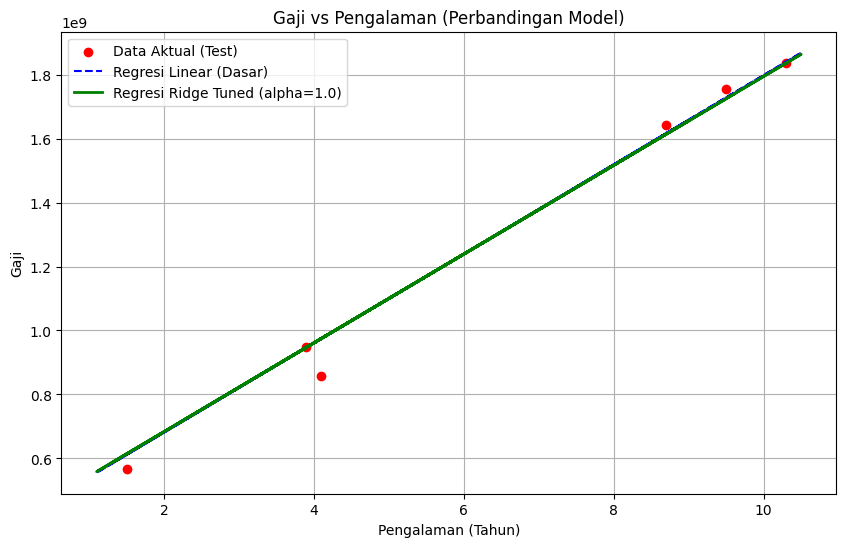

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ## Load Dataset
# load dataset
dataset = pd.read_csv('Data_Gaji.csv', delimiter=';')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 1].values

# ## Menampilkan Properti Data
# Menampilkan beberapa baris pertama dari dataset
print("Data Awal:")
print(dataset.head())
print("\n")

# Menampilkan informasi ringkas tentang dataset
print("Informasi Dataset:")
dataset.info()
print("\n")


# ## Membagi Data menjadi Data Train dan Data Test
# Import library untuk membagi data
from sklearn.model_selection import train_test_split

# Bagi dataset menjadi 80% data training dan 20% data test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


# ## Membuat Model Regresi Linear Sederhana (Sebagai Pembanding)
# Import library Regresi Linear
from sklearn.linear_model import LinearRegression

# Inisialisasi dan latih model Regresi Linear dasar
regressor = LinearRegression()
regressor.fit(X_train, y_train)


# ## Tuning Model dengan GridSearchCV
# Import library yang diperlukan untuk tuning
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# 1. Tentukan model yang akan di-tuning
model = Ridge()

# 2. Tentukan rentang hyperparameter yang akan diuji
# 'alpha' adalah parameter regularisasi untuk Ridge.
# Nilai yang lebih besar memberikan regularisasi yang lebih kuat.
params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 200.0]}

# 3. Siapkan GridSearchCV
# cv=5 berarti kita menggunakan 5-fold cross-validation
# scoring='neg_mean_squared_error' adalah metrik untuk mengevaluasi model,
# di mana nilai yang lebih dekat ke 0 lebih baik.
grid_search = GridSearchCV(estimator=model,
                           param_grid=params,
                           scoring='neg_mean_squared_error',
                           cv=5)

# 4. Lakukan proses training (fitting) untuk mencari parameter terbaik
grid_search.fit(X_train, y_train)

# Tampilkan hyperparameter terbaik yang ditemukan
print("Hyperparameter terbaik:", grid_search.best_params_)
print("Skor cross-validation terbaik (neg MSE):", grid_search.best_score_)
print("\n")


# ## Membuat Prediksi dengan Model yang Telah di-Tuning
# Dapatkan model terbaik dari hasil grid search
best_regressor = grid_search.best_estimator_

# Lakukan prediksi pada data test menggunakan model terbaik
y_pred_tuned = best_regressor.predict(X_test)

# Menampilkan hasil prediksi dari model yang sudah di-tuning
print("Hasil Prediksi (Tuned) vs Gaji Aktual:")
hasil_perbandingan_tuned = pd.DataFrame({'Gaji Aktual': y_test, 'Gaji Prediksi (Tuned)': y_pred_tuned})
print(hasil_perbandingan_tuned)
print("\n")


# ### Melakukan Visualisasi Data Hasil Tuning
# Visualisasikan perbandingan antara model linear dasar dan model hasil tuning
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', label='Data Aktual (Test)')

# Garis regresi dari model LinearRegression (sebelum tuning)
plt.plot(X_train, regressor.predict(X_train), color='blue', linestyle='--', label='Regresi Linear (Dasar)')

# Garis regresi dari model Ridge terbaik (setelah tuning)
plt.plot(X_train, best_regressor.predict(X_train), color='green', linewidth=2, label=f'Regresi Ridge Tuned (alpha={grid_search.best_params_["alpha"]})')

plt.title('Gaji vs Pengalaman (Perbandingan Model)')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji')
plt.legend()
plt.grid(True)
plt.show()